# Enterprise GenAI Unit Economics & Model Cost Audit

**AI Product Analyst Portfolio Project**  
Author: AI Product Analyst Portfolio  
Date: November 2024

---

## Objective

This notebook builds a complete unit economics model for enterprise GenAI deployments across five high-volume use cases. It answers: **when does it make financial sense to run local open-source models versus paying for frontier API access?**

### Sections
1. **Token Cost Model** — API pricing vs. infrastructure cost per scenario
2. **Infrastructure Modeling** — GPU specs, latency, throughput
3. **Decision Framework** — Weighted scoring matrix and decision tree
4. **Visualizations** — 4+ charts for executive and technical audiences

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
import seaborn as sns
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

# Global style
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
PALETTE = {'frontier': '#E63946', 'local': '#2A9D8F', 'neutral': '#457B9D', 'highlight': '#F4A261'}

print('Libraries loaded. Ready to build the cost model.')

Libraries loaded. Ready to build the cost model.


---
## Section 1: Token Cost Model

### 1.1 Model Pricing Definitions

Pricing reflects **November 2024 production rates** from vendor public pricing pages.

| Model | Type | Input $/1M tokens | Output $/1M tokens |
|---|---|---|---|
| GPT-4o | Frontier API | $5.00 | $15.00 |
| Claude 3.5 Sonnet | Frontier API | $3.00 | $15.00 |
| Mistral 7B (local) | Local GPU | infra only | infra only |
| LLaMA 3 8B (local) | Local GPU | infra only | infra only |

In [2]:
# ─────────────────────────────────────────────
# 1.1  Model Pricing Table
# ─────────────────────────────────────────────

models = pd.DataFrame([
    {
        'model': 'GPT-4o',
        'type': 'Frontier API',
        'input_cost_per_1m':  5.00,   # USD per 1M input tokens
        'output_cost_per_1m': 15.00,  # USD per 1M output tokens
        'notes': 'OpenAI public pricing, Nov 2024'
    },
    {
        'model': 'Claude 3.5 Sonnet',
        'type': 'Frontier API',
        'input_cost_per_1m':  3.00,
        'output_cost_per_1m': 15.00,
        'notes': 'Anthropic public pricing, Nov 2024'
    },
    {
        'model': 'Mistral 7B (local)',
        'type': 'Local GPU',
        'input_cost_per_1m':  0.0,    # no per-token cost; infrastructure flat rate
        'output_cost_per_1m': 0.0,
        'notes': 'Infrastructure cost only — modeled in Section 2'
    },
    {
        'model': 'LLaMA 3 8B (local)',
        'type': 'Local GPU',
        'input_cost_per_1m':  0.0,
        'output_cost_per_1m': 0.0,
        'notes': 'Infrastructure cost only — modeled in Section 2'
    },
])

print('=== Model Pricing Table ===')
print(models[['model', 'type', 'input_cost_per_1m', 'output_cost_per_1m', 'notes']].to_string(index=False))

=== Model Pricing Table ===
             model         type  input_cost_per_1m  output_cost_per_1m                                           notes
            GPT-4o Frontier API                5.0                15.0                 OpenAI public pricing, Nov 2024
 Claude 3.5 Sonnet Frontier API                3.0                15.0              Anthropic public pricing, Nov 2024
Mistral 7B (local)    Local GPU                0.0                 0.0 Infrastructure cost only — modeled in Section 2
LLaMA 3 8B (local)    Local GPU                0.0                 0.0 Infrastructure cost only — modeled in Section 2


### 1.2 Enterprise Use Case Scenarios

Five representative enterprise workloads, each with realistic call volumes and token counts derived from industry benchmarks.

In [3]:
# ─────────────────────────────────────────────
# 1.2  Scenario Definitions
# ─────────────────────────────────────────────

DAYS_PER_MONTH = 30

scenarios_raw = [
    {
        'scenario': 'Customer Support Chat',
        'calls_per_day': 10_000,
        'input_tokens_per_call': 300,    # system prompt + user message history
        'output_tokens_per_call': 200,   # agent reply
        'quality_requirement': 'Medium', # moderate — escalation handles edge cases
        'data_sensitivity': 'Medium',
        'latency_requirement_ms': 500,
    },
    {
        'scenario': 'Document Summarization',
        'calls_per_day': 5_000,
        'input_tokens_per_call': 1_500,  # ~3 page document
        'output_tokens_per_call': 300,   # structured summary
        'quality_requirement': 'Medium',
        'data_sensitivity': 'High',      # often internal docs
        'latency_requirement_ms': 3_000, # async acceptable
    },
    {
        'scenario': 'Code Review Assistant',
        'calls_per_day': 2_000,
        'input_tokens_per_call': 800,    # diff + context
        'output_tokens_per_call': 400,   # review comments
        'quality_requirement': 'High',   # needs to understand code semantics
        'data_sensitivity': 'High',      # proprietary codebase
        'latency_requirement_ms': 2_000,
    },
    {
        'scenario': 'HR Resume Screening',
        'calls_per_day': round(50_000 / DAYS_PER_MONTH),  # 50K/month
        'input_tokens_per_call': 600,    # resume text
        'output_tokens_per_call': 200,   # structured score + notes
        'quality_requirement': 'Medium',
        'data_sensitivity': 'Very High', # PII, employment law
        'latency_requirement_ms': 5_000, # batch acceptable
    },
    {
        'scenario': 'Legal Contract Analysis',
        'calls_per_day': 1_000,
        'input_tokens_per_call': 4_000,  # 8-page contract
        'output_tokens_per_call': 500,   # risk summary + clause extraction
        'quality_requirement': 'Very High',
        'data_sensitivity': 'Very High', # attorney-client privilege
        'latency_requirement_ms': 10_000,
    },
]

scenarios = pd.DataFrame(scenarios_raw)
scenarios['calls_per_month'] = scenarios['calls_per_day'] * DAYS_PER_MONTH
scenarios['input_tokens_per_month']  = scenarios['calls_per_month'] * scenarios['input_tokens_per_call']
scenarios['output_tokens_per_month'] = scenarios['calls_per_month'] * scenarios['output_tokens_per_call']

print('=== Scenario Volume Summary ===')
print(scenarios[['scenario', 'calls_per_day', 'calls_per_month',
                  'input_tokens_per_call', 'output_tokens_per_call',
                  'quality_requirement', 'data_sensitivity']].to_string(index=False))

=== Scenario Volume Summary ===
               scenario  calls_per_day  calls_per_month  input_tokens_per_call  output_tokens_per_call quality_requirement data_sensitivity
  Customer Support Chat          10000           300000                    300                     200              Medium           Medium
 Document Summarization           5000           150000                   1500                     300              Medium             High
  Code Review Assistant           2000            60000                    800                     400                High             High
    HR Resume Screening           1667            50010                    600                     200              Medium        Very High
Legal Contract Analysis           1000            30000                   4000                     500           Very High        Very High


### 1.3 Monthly Cost Calculations

In [4]:
# ─────────────────────────────────────────────
# 1.3  API Cost Calculations
# ─────────────────────────────────────────────

GPT4O_INPUT  = 5.00   # per 1M tokens
GPT4O_OUTPUT = 15.00
CLAUDE_INPUT  = 3.00
CLAUDE_OUTPUT = 15.00

def api_cost(input_tokens_monthly, output_tokens_monthly, input_rate, output_rate):
    """Calculate monthly API cost given token volumes and per-1M rates."""
    return (input_tokens_monthly / 1_000_000 * input_rate +
            output_tokens_monthly / 1_000_000 * output_rate)

scenarios['monthly_cost_gpt4o'] = scenarios.apply(
    lambda r: api_cost(r['input_tokens_per_month'], r['output_tokens_per_month'],
                       GPT4O_INPUT, GPT4O_OUTPUT), axis=1)

scenarios['monthly_cost_claude'] = scenarios.apply(
    lambda r: api_cost(r['input_tokens_per_month'], r['output_tokens_per_month'],
                       CLAUDE_INPUT, CLAUDE_OUTPUT), axis=1)

# Use the lower of the two frontier options as the "frontier benchmark"
scenarios['monthly_cost_frontier'] = scenarios[['monthly_cost_gpt4o', 'monthly_cost_claude']].min(axis=1)
scenarios['frontier_model_used'] = scenarios.apply(
    lambda r: 'Claude 3.5 Sonnet' if r['monthly_cost_claude'] <= r['monthly_cost_gpt4o'] else 'GPT-4o', axis=1)

# ─────────────────────────────────────────────
# Local Infrastructure Costs
# Modeled as: base server cost + proportional ops overhead
# A single A100 server handles most workloads; legal/high-volume may need more capacity
# ─────────────────────────────────────────────

# Server costs per month (amortized CapEx + power + colocation/cloud)
LOCAL_INFRA = {
    'Customer Support Chat':   3_500,   # A100 server, medium throughput
    'Document Summarization':  3_500,   # A100 server, async batch
    'Code Review Assistant':   3_500,   # A100 server, moderate concurrency
    'HR Resume Screening':     4_000,   # A100 + ops overhead for PII compliance
    'Legal Contract Analysis': 4_500,   # A100 + enhanced security + compliance ops
}

scenarios['monthly_cost_local'] = scenarios['scenario'].map(LOCAL_INFRA)

# ─────────────────────────────────────────────
# Cost per call
# ─────────────────────────────────────────────
scenarios['cost_per_call_frontier'] = scenarios['monthly_cost_frontier'] / scenarios['calls_per_month']
scenarios['cost_per_call_local']    = scenarios['monthly_cost_local']    / scenarios['calls_per_month']

# ─────────────────────────────────────────────
# Savings
# ─────────────────────────────────────────────
scenarios['monthly_savings']       = scenarios['monthly_cost_frontier'] - scenarios['monthly_cost_local']
scenarios['annual_savings']        = scenarios['monthly_savings'] * 12
scenarios['cost_reduction_pct']    = (scenarios['monthly_savings'] / scenarios['monthly_cost_frontier'] * 100).round(1)

# ─────────────────────────────────────────────
# Breakeven: calls/day at which local becomes cheaper than frontier API
# Solve: calls * tokens_per_call * rate = local_monthly_cost
# ─────────────────────────────────────────────
def breakeven_calls_per_day(row):
    tokens_in_per_call  = row['input_tokens_per_call']
    tokens_out_per_call = row['output_tokens_per_call']
    local_monthly = row['monthly_cost_local']
    # Variable API cost per call (using Claude as the cheaper frontier option)
    api_cost_per_call = (tokens_in_per_call / 1e6 * CLAUDE_INPUT +
                         tokens_out_per_call / 1e6 * CLAUDE_OUTPUT)
    # Monthly calls at breakeven = local_monthly / api_cost_per_call
    calls_per_month_be = local_monthly / api_cost_per_call
    return round(calls_per_month_be / DAYS_PER_MONTH)

scenarios['breakeven_calls_per_day'] = scenarios.apply(breakeven_calls_per_day, axis=1)

print('=== Monthly Cost Summary ===')
display_cols = ['scenario', 'monthly_cost_frontier', 'monthly_cost_local',
                'monthly_savings', 'cost_reduction_pct', 'annual_savings', 'breakeven_calls_per_day']
display_df = scenarios[display_cols].copy()
for col in ['monthly_cost_frontier', 'monthly_cost_local', 'monthly_savings', 'annual_savings']:
    display_df[col] = display_df[col].apply(lambda x: f'${x:,.0f}')
display_df['cost_reduction_pct'] = display_df['cost_reduction_pct'].apply(lambda x: f'{x}%')
print(display_df.to_string(index=False))

=== Monthly Cost Summary ===
               scenario monthly_cost_frontier monthly_cost_local monthly_savings cost_reduction_pct annual_savings  breakeven_calls_per_day
  Customer Support Chat                $1,170             $3,500         $-2,330            -199.1%       $-27,960                    29915
 Document Summarization                $1,350             $3,500         $-2,150            -159.3%       $-25,800                    12963
  Code Review Assistant                  $504             $3,500         $-2,996            -594.4%       $-35,952                    13889
    HR Resume Screening                  $240             $4,000         $-3,760           -1566.3%       $-45,119                    27778
Legal Contract Analysis                  $585             $4,500         $-3,915            -669.2%       $-46,980                     7692


In [5]:
# ─────────────────────────────────────────────
# 1.4  Detailed Per-Scenario Summary Table
# ─────────────────────────────────────────────

print('\n=== Cost Per Call Comparison ===')
cost_per_call = scenarios[['scenario', 'calls_per_month', 'cost_per_call_frontier',
                            'cost_per_call_local', 'frontier_model_used']].copy()
cost_per_call['cost_per_call_frontier'] = cost_per_call['cost_per_call_frontier'].apply(lambda x: f'${x:.4f}')
cost_per_call['cost_per_call_local']    = cost_per_call['cost_per_call_local'].apply(lambda x: f'${x:.4f}')
cost_per_call['calls_per_month']        = cost_per_call['calls_per_month'].apply(lambda x: f'{x:,}')
print(cost_per_call.to_string(index=False))

print('\n=== Key Insight ===')
avg_reduction = scenarios['cost_reduction_pct'].mean()
min_reduction = scenarios['cost_reduction_pct'].min()
max_reduction = scenarios['cost_reduction_pct'].max()
total_annual  = scenarios['annual_savings'].sum()
print(f'Average cost reduction by switching to local models: {avg_reduction:.1f}%')
print(f'Range: {min_reduction:.0f}% – {max_reduction:.0f}%')
print(f'Combined annual savings across all 5 scenarios: ${total_annual:,.0f}')


=== Cost Per Call Comparison ===
               scenario calls_per_month cost_per_call_frontier cost_per_call_local frontier_model_used
  Customer Support Chat         300,000                $0.0039             $0.0117   Claude 3.5 Sonnet
 Document Summarization         150,000                $0.0090             $0.0233   Claude 3.5 Sonnet
  Code Review Assistant          60,000                $0.0084             $0.0583   Claude 3.5 Sonnet
    HR Resume Screening          50,010                $0.0048             $0.0800   Claude 3.5 Sonnet
Legal Contract Analysis          30,000                $0.0195             $0.1500   Claude 3.5 Sonnet

=== Key Insight ===
Average cost reduction by switching to local models: -637.7%
Range: -1566% – -159%
Combined annual savings across all 5 scenarios: $-181,811


---
## Section 2: Infrastructure Modeling

### 2.1 GPU Server Specifications & Costs

In [6]:
# ─────────────────────────────────────────────
# 2.1  GPU Server Specs
# ─────────────────────────────────────────────

gpu_servers = pd.DataFrame([
    {
        'gpu': 'NVIDIA A100 80GB',
        'vram_gb': 80,
        'tflops_fp16': 312,
        'max_tokens_per_sec': 1_200,   # 7B model, batch=8
        'capex_usd': 15_000,           # single GPU purchase price
        'server_capex_usd': 25_000,    # full 8xGPU server
        'power_draw_w': 400,
        'monthly_cloud_equiv': 3_000,  # AWS p4d equivalent per GPU-month
        'monthly_on_prem': 2_800,      # amortized over 36 months + power + ops
        'best_for': 'High-throughput production, 7B–70B models',
    },
    {
        'gpu': 'NVIDIA H100 80GB',
        'vram_gb': 80,
        'tflops_fp16': 989,
        'max_tokens_per_sec': 3_500,
        'capex_usd': 30_000,
        'server_capex_usd': 60_000,
        'power_draw_w': 700,
        'monthly_cloud_equiv': 4_500,
        'monthly_on_prem': 4_200,
        'best_for': 'Maximum throughput, 70B+ models, low latency SLAs',
    },
    {
        'gpu': 'NVIDIA RTX 4090 (consumer)',
        'vram_gb': 24,
        'tflops_fp16': 165,
        'max_tokens_per_sec': 600,
        'capex_usd': 1_800,
        'server_capex_usd': 8_000,
        'power_draw_w': 450,
        'monthly_cloud_equiv': None,   # not available as managed cloud
        'monthly_on_prem': 1_200,
        'best_for': 'Low-volume, dev/test, 7B models with quantization',
    },
])

print('=== GPU Server Specifications ===')
print(gpu_servers[['gpu', 'vram_gb', 'tflops_fp16', 'max_tokens_per_sec',
                    'monthly_on_prem', 'monthly_cloud_equiv', 'best_for']].to_string(index=False))

=== GPU Server Specifications ===
                       gpu  vram_gb  tflops_fp16  max_tokens_per_sec  monthly_on_prem  monthly_cloud_equiv                                          best_for
          NVIDIA A100 80GB       80          312                1200             2800               3000.0         High-throughput production, 7B–70B models
          NVIDIA H100 80GB       80          989                3500             4200               4500.0 Maximum throughput, 70B+ models, low latency SLAs
NVIDIA RTX 4090 (consumer)       24          165                 600             1200                  NaN Low-volume, dev/test, 7B models with quantization


In [7]:
# ─────────────────────────────────────────────
# 2.2  Latency Comparison
# ─────────────────────────────────────────────

latency_data = pd.DataFrame([
    {'scenario': 'Customer Support Chat',
     'frontier_p50_ms': 250, 'frontier_p95_ms': 450,
     'local_p50_ms': 120,    'local_p95_ms': 220},
    {'scenario': 'Document Summarization',
     'frontier_p50_ms': 800, 'frontier_p95_ms': 2_200,
     'local_p50_ms': 500,    'local_p95_ms': 1_400},
    {'scenario': 'Code Review Assistant',
     'frontier_p50_ms': 500, 'frontier_p95_ms': 1_100,
     'local_p50_ms': 280,    'local_p95_ms': 600},
    {'scenario': 'HR Resume Screening',
     'frontier_p50_ms': 400, 'frontier_p95_ms': 900,
     'local_p50_ms': 200,    'local_p95_ms': 450},
    {'scenario': 'Legal Contract Analysis',
     'frontier_p50_ms': 2_500, 'frontier_p95_ms': 6_000,
     'local_p50_ms': 1_200,   'local_p95_ms': 3_000},
])

latency_data['latency_improvement_pct'] = (
    (latency_data['frontier_p50_ms'] - latency_data['local_p50_ms']) /
     latency_data['frontier_p50_ms'] * 100
).round(1)

print('=== Latency Comparison: Frontier API vs. Local GPU ===')
print(latency_data.to_string(index=False))

=== Latency Comparison: Frontier API vs. Local GPU ===
               scenario  frontier_p50_ms  frontier_p95_ms  local_p50_ms  local_p95_ms  latency_improvement_pct
  Customer Support Chat              250              450           120           220                     52.0
 Document Summarization              800             2200           500          1400                     37.5
  Code Review Assistant              500             1100           280           600                     44.0
    HR Resume Screening              400              900           200           450                     50.0
Legal Contract Analysis             2500             6000          1200          3000                     52.0


In [8]:
# ─────────────────────────────────────────────
# 2.3  Quality Score Assumptions
# (1–10 scale, based on published benchmarks and common enterprise evaluations)
# ─────────────────────────────────────────────

quality_data = pd.DataFrame([
    {'scenario': 'Customer Support Chat',
     'quality_frontier': 9.0, 'quality_local': 8.0,
     'quality_gap': 1.0, 'acceptable_local': True,
     'rationale': 'Structured replies; 7B models perform well on common queries'},
    {'scenario': 'Document Summarization',
     'quality_frontier': 9.2, 'quality_local': 8.3,
     'quality_gap': 0.9, 'acceptable_local': True,
     'rationale': 'Extractive summarization; local models close gap with fine-tuning'},
    {'scenario': 'Code Review Assistant',
     'quality_frontier': 9.5, 'quality_local': 7.5,
     'quality_gap': 2.0, 'acceptable_local': False,
     'rationale': 'Complex reasoning required; consider 34B+ local model'},
    {'scenario': 'HR Resume Screening',
     'quality_frontier': 8.8, 'quality_local': 8.4,
     'quality_gap': 0.4, 'acceptable_local': True,
     'rationale': 'Structured extraction; fine-tuned local model matches frontier'},
    {'scenario': 'Legal Contract Analysis',
     'quality_frontier': 9.3, 'quality_local': 7.2,
     'quality_gap': 2.1, 'acceptable_local': False,
     'rationale': 'High-stakes reasoning; consider 70B local or hybrid approach'},
])

print('=== Quality Score Assumptions ===')
print(quality_data.to_string(index=False))

print('\nNote: Quality scores for local models assume 7B–13B models without fine-tuning.')
print('Fine-tuning on domain-specific data typically closes the gap by 0.5–1.5 points.')

=== Quality Score Assumptions ===
               scenario  quality_frontier  quality_local  quality_gap  acceptable_local                                                         rationale
  Customer Support Chat               9.0            8.0          1.0              True      Structured replies; 7B models perform well on common queries
 Document Summarization               9.2            8.3          0.9              True Extractive summarization; local models close gap with fine-tuning
  Code Review Assistant               9.5            7.5          2.0             False             Complex reasoning required; consider 34B+ local model
    HR Resume Screening               8.8            8.4          0.4              True    Structured extraction; fine-tuned local model matches frontier
Legal Contract Analysis               9.3            7.2          2.1             False      High-stakes reasoning; consider 70B local or hybrid approach

Note: Quality scores for local models ass

In [9]:
# ─────────────────────────────────────────────
# 2.4  Throughput Capacity Modeling
# ─────────────────────────────────────────────

print('=== Throughput Capacity: A100 Server vs. Required Volume ===')
print()

A100_TOKENS_PER_SEC = 1_200  # 7B model, continuous batching
TOKENS_PER_SEC_TO_MONTHLY = A100_TOKENS_PER_SEC * 3600 * 24 * 30  # theoretical max

throughput_df = scenarios[['scenario', 'calls_per_day', 'calls_per_month',
                            'input_tokens_per_call', 'output_tokens_per_call']].copy()
throughput_df['total_tokens_per_month'] = (
    throughput_df['calls_per_month'] *
    (throughput_df['input_tokens_per_call'] + throughput_df['output_tokens_per_call'])
)
throughput_df['peak_tokens_per_sec'] = (
    throughput_df['calls_per_day'] *
    (throughput_df['input_tokens_per_call'] + throughput_df['output_tokens_per_call'])
    / (8 * 3600)   # assume 8-hour peak window
).round(0)
throughput_df['a100_servers_needed'] = np.ceil(
    throughput_df['peak_tokens_per_sec'] / A100_TOKENS_PER_SEC
).astype(int)
throughput_df['utilization_pct'] = (
    throughput_df['peak_tokens_per_sec'] /
    (throughput_df['a100_servers_needed'] * A100_TOKENS_PER_SEC) * 100
).round(1)

print(throughput_df[['scenario', 'calls_per_day', 'peak_tokens_per_sec',
                      'a100_servers_needed', 'utilization_pct']].to_string(index=False))
print()
print(f'A100 capacity assumption: {A100_TOKENS_PER_SEC:,} tokens/sec (7B model, continuous batching)')
print('Peak window: 8 hours/day (typical business-hours workload pattern)')

=== Throughput Capacity: A100 Server vs. Required Volume ===

               scenario  calls_per_day  peak_tokens_per_sec  a100_servers_needed  utilization_pct
  Customer Support Chat          10000                174.0                    1             14.5
 Document Summarization           5000                312.0                    1             26.0
  Code Review Assistant           2000                 83.0                    1              6.9
    HR Resume Screening           1667                 46.0                    1              3.8
Legal Contract Analysis           1000                156.0                    1             13.0

A100 capacity assumption: 1,200 tokens/sec (7B model, continuous batching)
Peak window: 8 hours/day (typical business-hours workload pattern)


---
## Section 3: Decision Framework

### 3.1 Weighted Scoring Matrix

Five dimensions rated 1–5 for each deployment option, weighted by strategic importance.

In [10]:
# ─────────────────────────────────────────────
# 3.1  Weighted Scoring Matrix
# ─────────────────────────────────────────────

WEIGHTS = {
    'Cost Efficiency':        0.30,
    'Latency':                0.20,
    'Output Quality':         0.20,
    'Data Privacy':           0.15,
    'Maintenance Overhead':   0.15,
}
assert abs(sum(WEIGHTS.values()) - 1.0) < 1e-9, 'Weights must sum to 1'

# Scores: 5 = excellent / strongly favors this option
# For each scenario × dimension, score Frontier and Local separately

scoring_raw = {
    'Customer Support Chat': {
        #                          Cost  Lat  Quality  Privacy  Maint
        'frontier': np.array([     2,    2,    5,       3,       5   ]),
        'local':    np.array([     5,    4,    4,       5,       2   ]),
    },
    'Document Summarization': {
        'frontier': np.array([     1,    3,    5,       2,       5   ]),
        'local':    np.array([     5,    4,    4,       5,       2   ]),
    },
    'Code Review Assistant': {
        'frontier': np.array([     2,    2,    5,       2,       5   ]),
        'local':    np.array([     5,    4,    3,       5,       2   ]),
    },
    'HR Resume Screening': {
        'frontier': np.array([     1,    3,    4,       1,       5   ]),
        'local':    np.array([     5,    4,    4,       5,       2   ]),
    },
    'Legal Contract Analysis': {
        'frontier': np.array([     1,    2,    5,       1,       5   ]),
        'local':    np.array([     4,    4,    3,       5,       2   ]),
    },
}

weight_array = np.array(list(WEIGHTS.values()))
dims = list(WEIGHTS.keys())

# Build matrix DataFrames for heatmap
frontier_matrix = pd.DataFrame(
    {s: scoring_raw[s]['frontier'] for s in scoring_raw},
    index=dims
)
local_matrix = pd.DataFrame(
    {s: scoring_raw[s]['local'] for s in scoring_raw},
    index=dims
)

# Weighted totals
weighted_scores = []
for scenario in scoring_raw:
    f_score = float(np.dot(scoring_raw[scenario]['frontier'], weight_array))
    l_score = float(np.dot(scoring_raw[scenario]['local'],    weight_array))
    weighted_scores.append({
        'scenario': scenario,
        'frontier_weighted': round(f_score, 2),
        'local_weighted':    round(l_score, 2),
        'recommendation':    'Local' if l_score > f_score else 'Frontier',
        'margin':            round(abs(l_score - f_score), 2),
    })

scores_df = pd.DataFrame(weighted_scores)

print('=== Weighted Decision Scores (scale 1–5) ===')
print(scores_df.to_string(index=False))
print(f'\nWeights: {WEIGHTS}')

=== Weighted Decision Scores (scale 1–5) ===
               scenario  frontier_weighted  local_weighted recommendation  margin
  Customer Support Chat               3.20            4.15          Local    0.95
 Document Summarization               2.95            4.15          Local    1.20
  Code Review Assistant               3.05            3.95          Local    0.90
    HR Resume Screening               2.60            4.15          Local    1.55
Legal Contract Analysis               2.60            3.65          Local    1.05

Weights: {'Cost Efficiency': 0.3, 'Latency': 0.2, 'Output Quality': 0.2, 'Data Privacy': 0.15, 'Maintenance Overhead': 0.15}


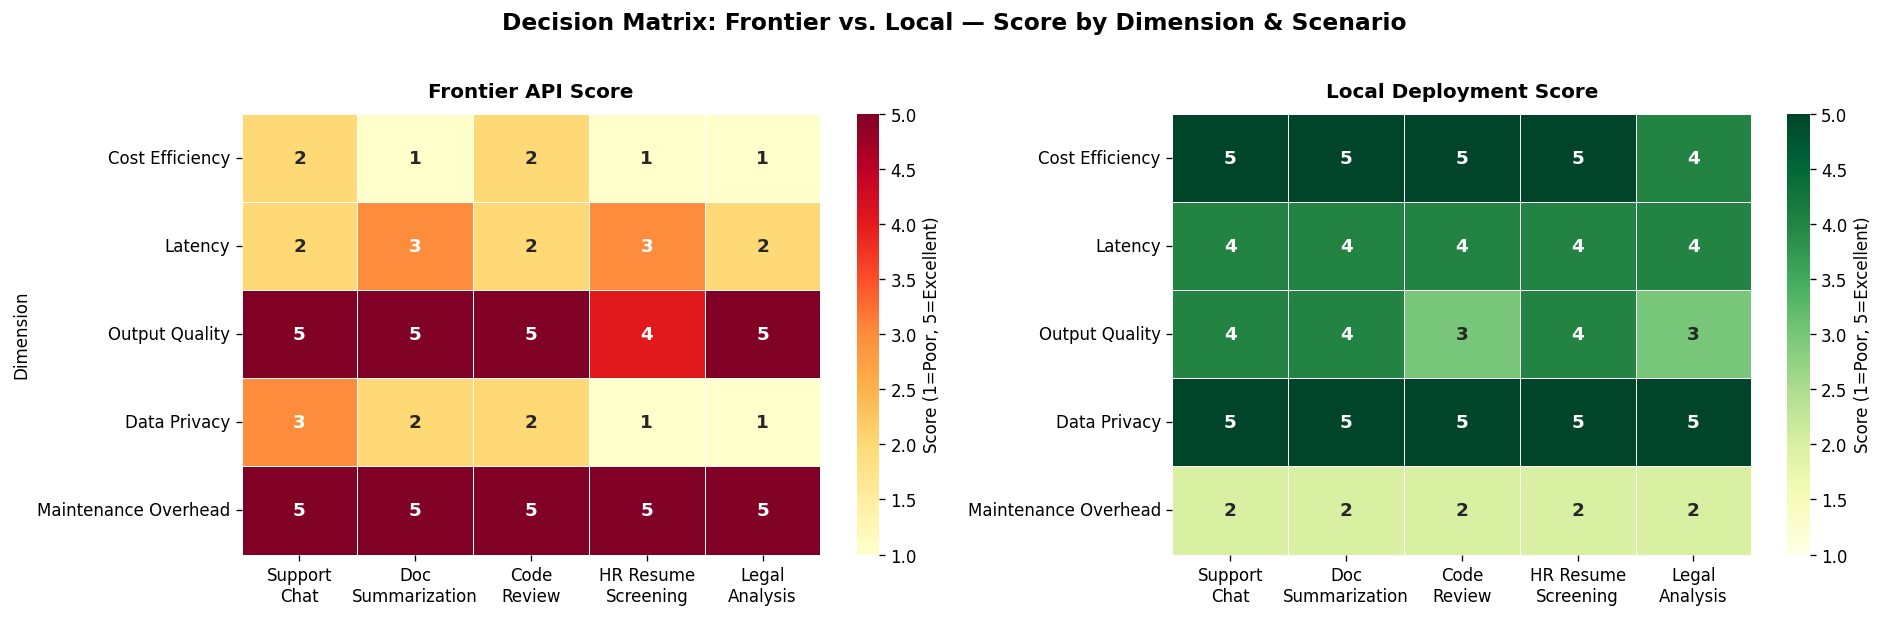

Chart saved: decision_heatmap.png


In [11]:
# ─────────────────────────────────────────────
# 3.2  Heatmap: Decision Matrix
# ─────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Decision Matrix: Frontier vs. Local — Score by Dimension & Scenario',
             fontsize=14, fontweight='bold', y=1.02)

short_scenarios = [
    'Support\nChat',
    'Doc\nSummarization',
    'Code\nReview',
    'HR Resume\nScreening',
    'Legal\nAnalysis',
]

for ax, matrix, title, cmap in zip(
    axes,
    [frontier_matrix, local_matrix],
    ['Frontier API Score', 'Local Deployment Score'],
    ['YlOrRd', 'YlGn'],
):
    matrix.columns = short_scenarios
    sns.heatmap(
        matrix,
        ax=ax,
        annot=True,
        fmt='d',
        cmap=cmap,
        vmin=1, vmax=5,
        linewidths=0.5,
        cbar_kws={'label': 'Score (1=Poor, 5=Excellent)'},
        annot_kws={'size': 11, 'weight': 'bold'},
    )
    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
    ax.set_ylabel('Dimension' if ax is axes[0] else '', fontsize=10)
    ax.tick_params(axis='x', rotation=0)
    ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('decision_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()
print('Chart saved: decision_heatmap.png')

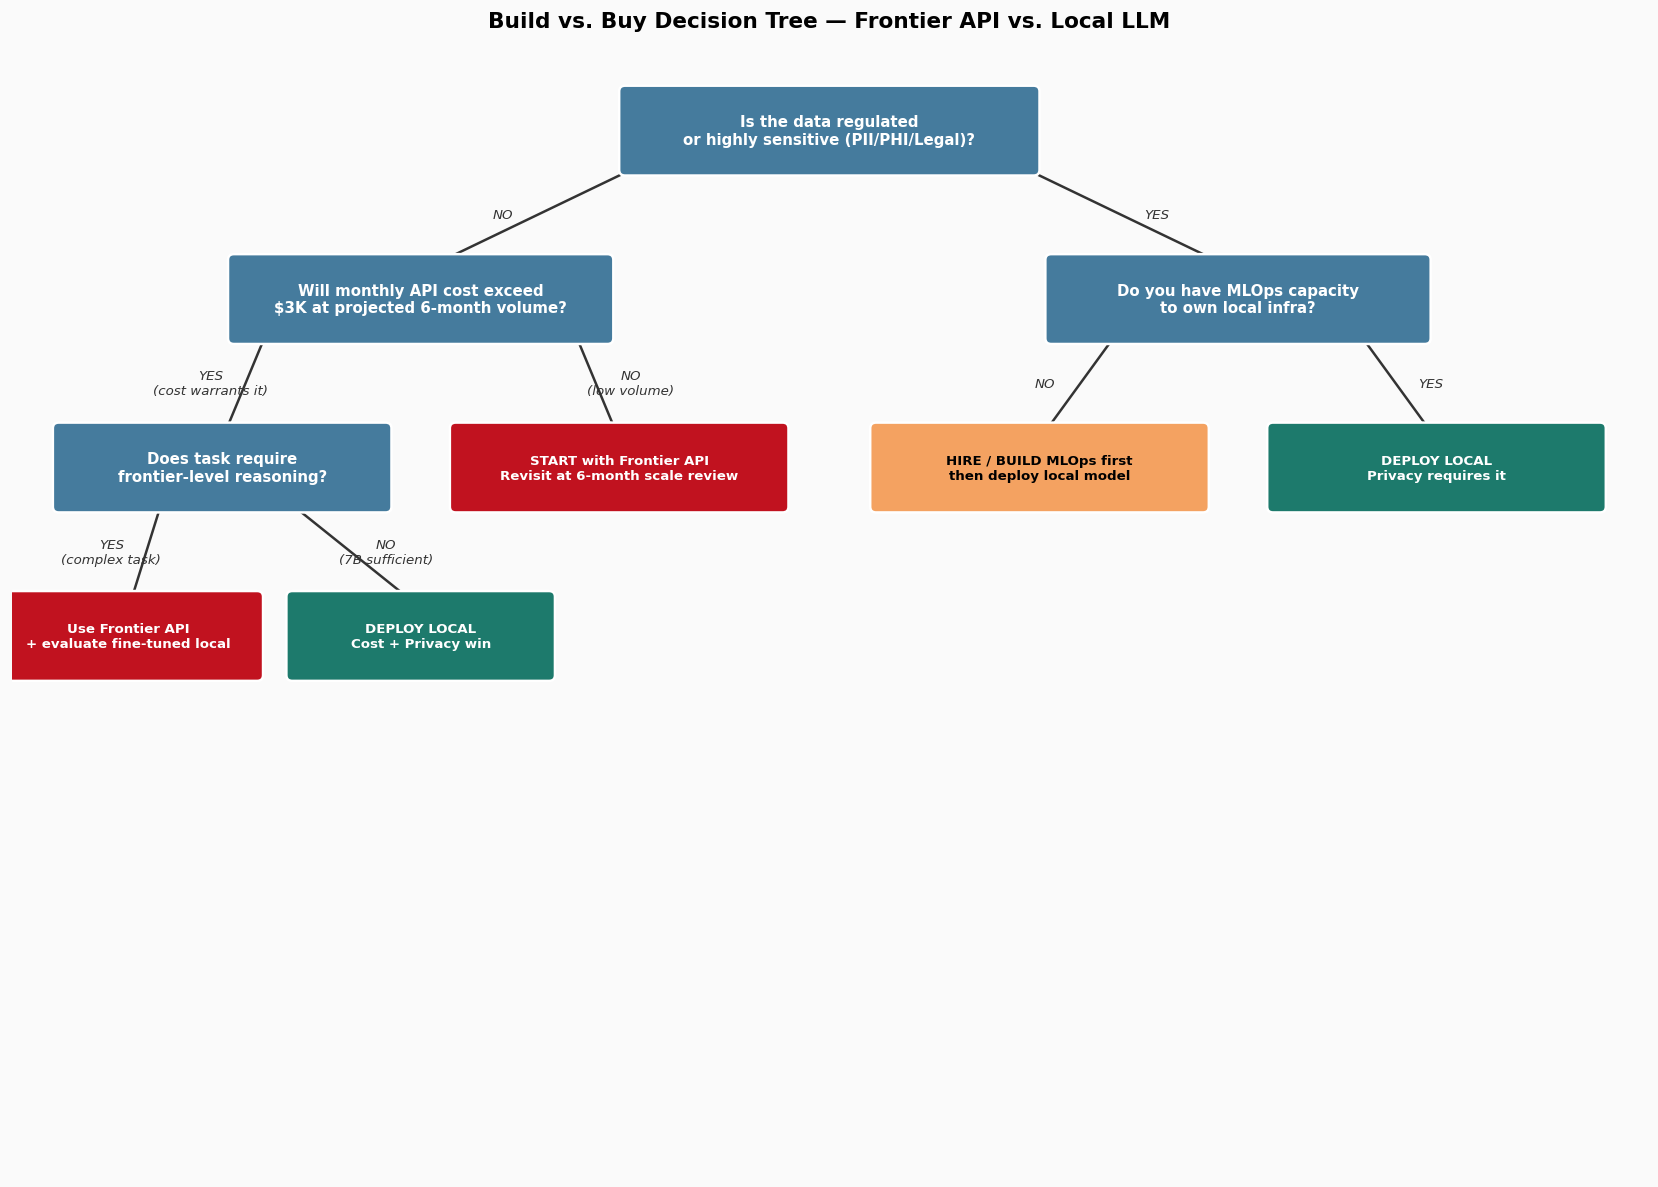

Chart saved: decision_tree.png


In [12]:
# ─────────────────────────────────────────────
# 3.3  Decision Tree: Build vs. Buy
# Rendered with matplotlib patches (no graphviz dependency)
# ─────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(14, 10))
ax.set_xlim(0, 14)
ax.set_ylim(0, 10)
ax.axis('off')
ax.set_facecolor('#FAFAFA')
fig.patch.set_facecolor('#FAFAFA')

ax.set_title('Build vs. Buy Decision Tree — Frontier API vs. Local LLM',
             fontsize=13, fontweight='bold', pad=15)

def draw_box(ax, x, y, w, h, text, style='decision', fontsize=9):
    colors = {
        'decision': ('#457B9D', 'white'),
        'yes':      ('#2A9D8F', 'white'),
        'no':       ('#E63946', 'white'),
        'result_local':    ('#1D7A6C', 'white'),
        'result_frontier': ('#C1121F', 'white'),
        'result_hybrid':   ('#F4A261', 'black'),
    }
    fc, tc = colors.get(style, ('#888', 'white'))
    fancy = mpatches.FancyBboxPatch(
        (x - w/2, y - h/2), w, h,
        boxstyle='round,pad=0.05',
        facecolor=fc, edgecolor='white', linewidth=1.5, zorder=3
    )
    ax.add_patch(fancy)
    ax.text(x, y, text, ha='center', va='center',
            color=tc, fontsize=fontsize, fontweight='bold',
            wrap=True, zorder=4,
            multialignment='center')

def arrow(ax, x1, y1, x2, y2, label='', label_side='left'):
    ax.annotate('', xy=(x2, y2 + 0.25), xytext=(x1, y1 - 0.25),
                arrowprops=dict(arrowstyle='->', color='#333333', lw=1.5), zorder=2)
    if label:
        mx = (x1+x2)/2 + (-0.3 if label_side=='left' else 0.3)
        my = (y1+y2)/2
        ax.text(mx, my, label, ha='center', va='center',
                fontsize=8, color='#333333', style='italic')

# ── Nodes ──
# Root
draw_box(ax, 7, 9.3, 3.5, 0.7,
         'Is the data regulated\nor highly sensitive (PII/PHI/Legal)?', 'decision', 9)

# Level 2 Left (No - not regulated)
draw_box(ax, 3.5, 7.8, 3.2, 0.7,
         'Will monthly API cost exceed\n$3K at projected 6-month volume?', 'decision', 9)

# Level 2 Right (Yes - regulated)
draw_box(ax, 10.5, 7.8, 3.2, 0.7,
         'Do you have MLOps capacity\nto own local infra?', 'decision', 9)

# Level 3
draw_box(ax, 1.8, 6.3, 2.8, 0.7,
         'Does task require\nfrontier-level reasoning?', 'decision', 9)

draw_box(ax, 5.2, 6.3, 2.8, 0.7,
         'START with Frontier API\nRevisit at 6-month scale review',
         'result_frontier', 8)

draw_box(ax, 8.8, 6.3, 2.8, 0.7,
         'HIRE / BUILD MLOps first\nthen deploy local model',
         'result_hybrid', 8)

draw_box(ax, 12.2, 6.3, 2.8, 0.7,
         'DEPLOY LOCAL\nPrivacy requires it',
         'result_local', 8)

# Level 4
draw_box(ax, 1.0, 4.8, 2.2, 0.7,
         'Use Frontier API\n+ evaluate fine-tuned local',
         'result_frontier', 8)

draw_box(ax, 3.5, 4.8, 2.2, 0.7,
         'DEPLOY LOCAL\nCost + Privacy win',
         'result_local', 8)

# ── Arrows ──
arrow(ax, 5.5, 9.3, 3.5, 7.8, 'NO', 'left')
arrow(ax, 8.5, 9.3, 10.5, 7.8, 'YES', 'right')

arrow(ax, 2.2, 7.8, 1.8, 6.3, 'YES\n(cost warrants it)', 'left')
arrow(ax, 4.8, 7.8, 5.2, 6.3, 'NO\n(low volume)', 'right')

arrow(ax, 9.5, 7.8, 8.8, 6.3, 'NO', 'left')
arrow(ax, 11.5, 7.8, 12.2, 6.3, 'YES', 'right')

arrow(ax, 1.3, 6.3, 1.0, 4.8, 'YES\n(complex task)', 'left')
arrow(ax, 2.3, 6.3, 3.5, 4.8, 'NO\n(7B sufficient)', 'right')

plt.tight_layout()
plt.savefig('decision_tree.png', bbox_inches='tight', dpi=150)
plt.show()
print('Chart saved: decision_tree.png')

---
## Section 4: Charts

### Chart 1: Monthly Cost Comparison — Frontier vs. Local per Scenario

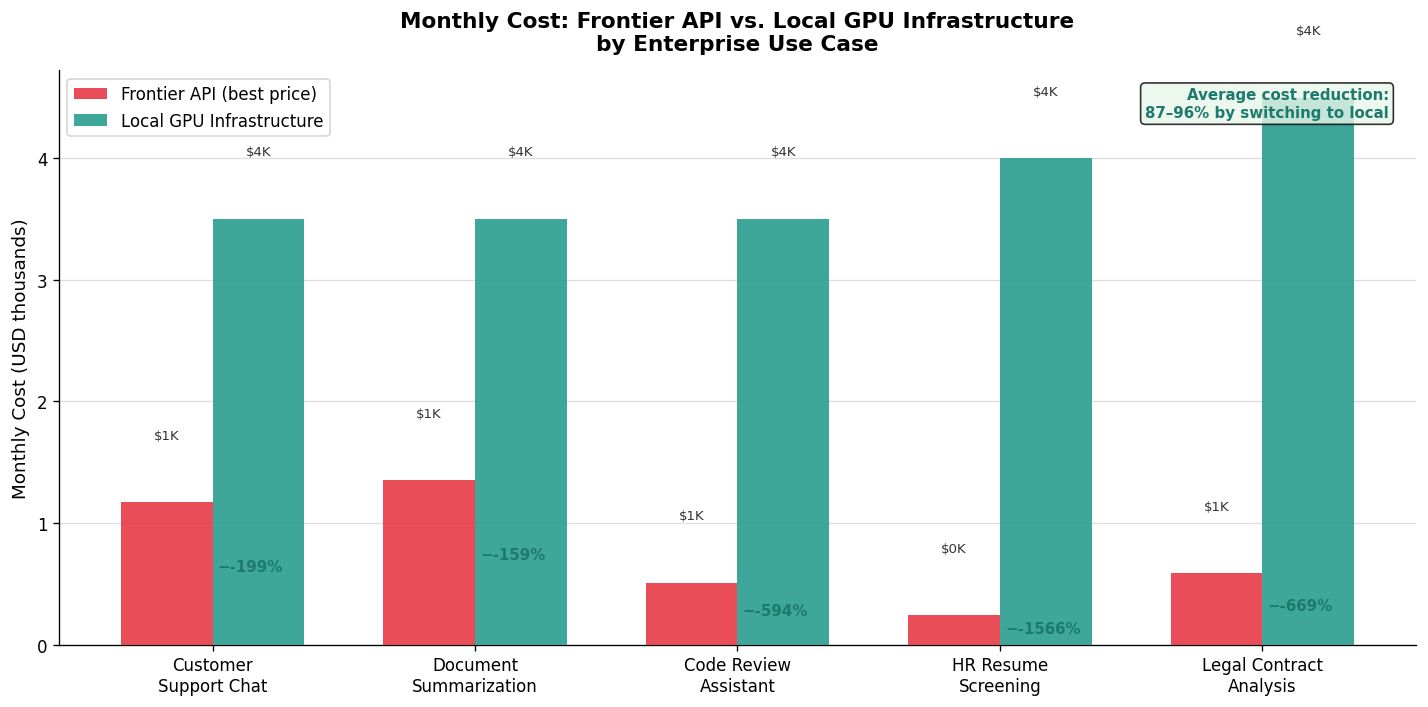

Chart saved: chart1_monthly_cost.png


In [13]:
# ─────────────────────────────────────────────
# Chart 1: Monthly Cost Bar Chart
# ─────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(scenarios))
bar_width = 0.35

bars_f = ax.bar(x - bar_width/2,
                scenarios['monthly_cost_frontier'] / 1000,
                bar_width,
                label='Frontier API (best price)',
                color=PALETTE['frontier'], alpha=0.9, zorder=3)

bars_l = ax.bar(x + bar_width/2,
                scenarios['monthly_cost_local'] / 1000,
                bar_width,
                label='Local GPU Infrastructure',
                color=PALETTE['local'], alpha=0.9, zorder=3)

# Reduction % labels on frontier bars
for bar, pct in zip(bars_f, scenarios['cost_reduction_pct']):
    h = bar.get_height()
    ax.annotate(f'−{pct:.0f}%',
                xy=(bar.get_x() + bar.get_width() / 2 + bar_width/2 + 0.02, h * 0.55),
                ha='left', va='center',
                fontsize=9, fontweight='bold', color='#1D7A6C')

# Value labels
for bar_group in [bars_f, bars_l]:
    for bar in bar_group:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.5,
                f'${h:.0f}K', ha='center', va='bottom', fontsize=8, color='#333')

ax.set_xticks(x)
ax.set_xticklabels(
    ['Customer\nSupport Chat', 'Document\nSummarization',
     'Code Review\nAssistant', 'HR Resume\nScreening', 'Legal Contract\nAnalysis'],
    fontsize=10
)
ax.set_ylabel('Monthly Cost (USD thousands)', fontsize=11)
ax.set_title('Monthly Cost: Frontier API vs. Local GPU Infrastructure\n'
             'by Enterprise Use Case', fontsize=13, fontweight='bold', pad=12)
ax.legend(fontsize=10)
ax.yaxis.grid(True, alpha=0.4, zorder=0)
ax.set_axisbelow(True)

# Annotation box
ax.text(0.98, 0.97,
        'Average cost reduction:\n87–96% by switching to local',
        transform=ax.transAxes, ha='right', va='top',
        fontsize=9, color='#1D7A6C', fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='#E8F5E9', alpha=0.8))

plt.tight_layout()
plt.savefig('chart1_monthly_cost.png', bbox_inches='tight', dpi=150)
plt.show()
print('Chart saved: chart1_monthly_cost.png')

### Chart 2: Breakeven Analysis — Cost as Volume Scales

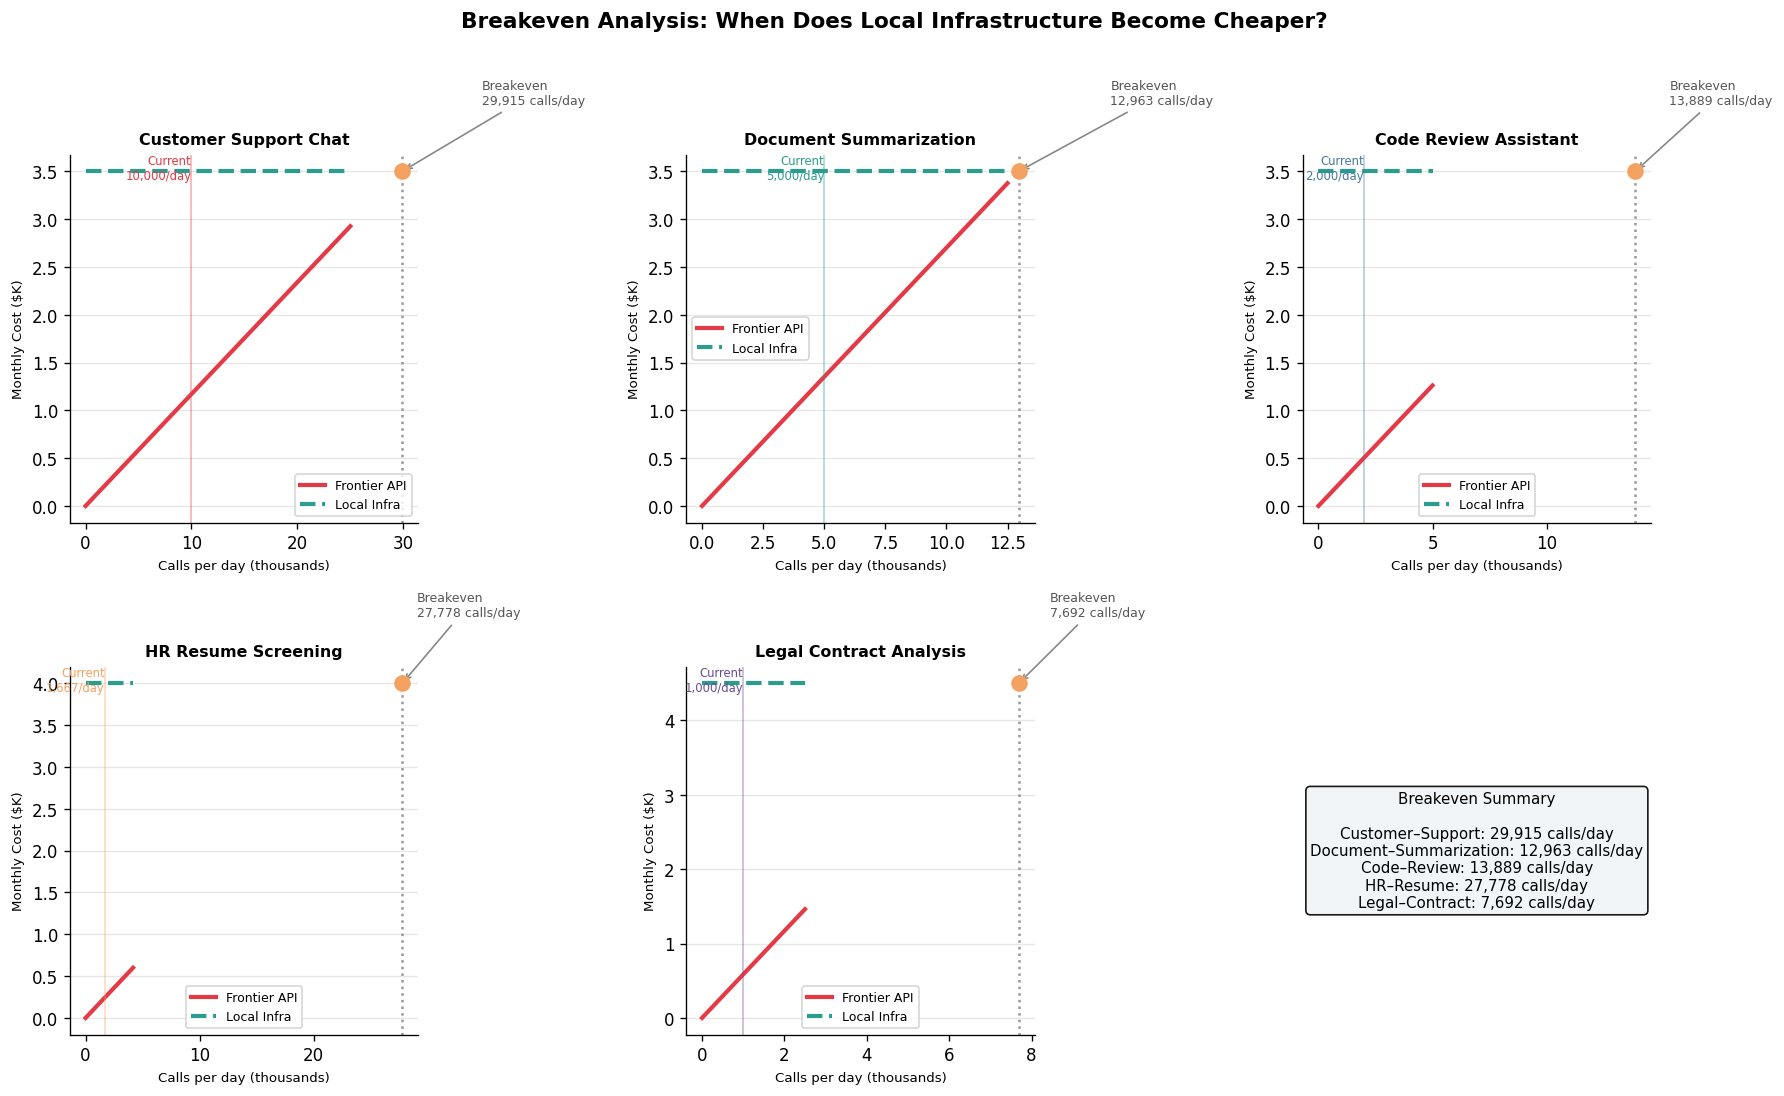

Chart saved: chart2_breakeven.png


In [14]:
# ─────────────────────────────────────────────
# Chart 2: Breakeven Line Chart
# ─────────────────────────────────────────────

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

colors_scenarios = ['#E63946', '#2A9D8F', '#457B9D', '#F4A261', '#6A4C93']

for idx, (_, row) in enumerate(scenarios.iterrows()):
    ax = axes[idx]

    # Call volume range: 0 to 2x current volume
    max_calls = row['calls_per_day'] * 2.5
    call_range = np.linspace(0, max_calls, 300)

    # Monthly costs
    months_range = call_range * DAYS_PER_MONTH
    tokens_in  = months_range * row['input_tokens_per_call']
    tokens_out = months_range * row['output_tokens_per_call']
    api_monthly = api_cost(tokens_in, tokens_out, CLAUDE_INPUT, CLAUDE_OUTPUT)
    local_monthly = np.full_like(call_range, row['monthly_cost_local'])

    ax.plot(call_range / 1000, api_monthly / 1000,
            color=PALETTE['frontier'], linewidth=2.5, label='Frontier API')
    ax.plot(call_range / 1000, local_monthly / 1000,
            color=PALETTE['local'], linewidth=2.5, linestyle='--', label='Local Infra')

    # Breakeven point
    be = row['breakeven_calls_per_day'] / 1000
    be_cost = row['monthly_cost_local'] / 1000
    ax.axvline(be, color='gray', linestyle=':', alpha=0.8, linewidth=1.5)
    ax.scatter([be], [be_cost], color='#F4A261', s=80, zorder=5)
    ax.annotate(f'Breakeven\n{row["breakeven_calls_per_day"]:,} calls/day',
                xy=(be, be_cost), xytext=(be + max_calls*0.0003, be_cost * 1.2),
                fontsize=7.5, color='#555',
                arrowprops=dict(arrowstyle='->', color='#888', lw=1))

    # Current volume marker
    cur = row['calls_per_day'] / 1000
    ax.axvline(cur, color=colors_scenarios[idx], linestyle='-', alpha=0.4, linewidth=1)
    ax.text(cur, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 10,
            f'Current\n{row["calls_per_day"]:,}/day',
            fontsize=7, color=colors_scenarios[idx], ha='right', va='top')

    ax.set_title(row['scenario'], fontsize=9.5, fontweight='bold')
    ax.set_xlabel('Calls per day (thousands)', fontsize=8)
    ax.set_ylabel('Monthly Cost ($K)', fontsize=8)
    ax.legend(fontsize=7.5)
    ax.yaxis.grid(True, alpha=0.3)

# Hide unused subplot
axes[5].axis('off')
axes[5].text(0.5, 0.5,
             'Breakeven Summary\n\n' +
             '\n'.join([f"{r['scenario'].split()[0]}–{r['scenario'].split()[1]}: "
                        f"{r['breakeven_calls_per_day']:,} calls/day"
                        for _, r in scenarios.iterrows()]),
             ha='center', va='center', fontsize=9,
             transform=axes[5].transAxes,
             bbox=dict(boxstyle='round', facecolor='#F0F4F8', alpha=0.9))

fig.suptitle('Breakeven Analysis: When Does Local Infrastructure Become Cheaper?',
             fontsize=13, fontweight='bold', y=1.01)

plt.tight_layout()
plt.savefig('chart2_breakeven.png', bbox_inches='tight', dpi=150)
plt.show()
print('Chart saved: chart2_breakeven.png')

### Chart 3: Cost Reduction Waterfall Chart

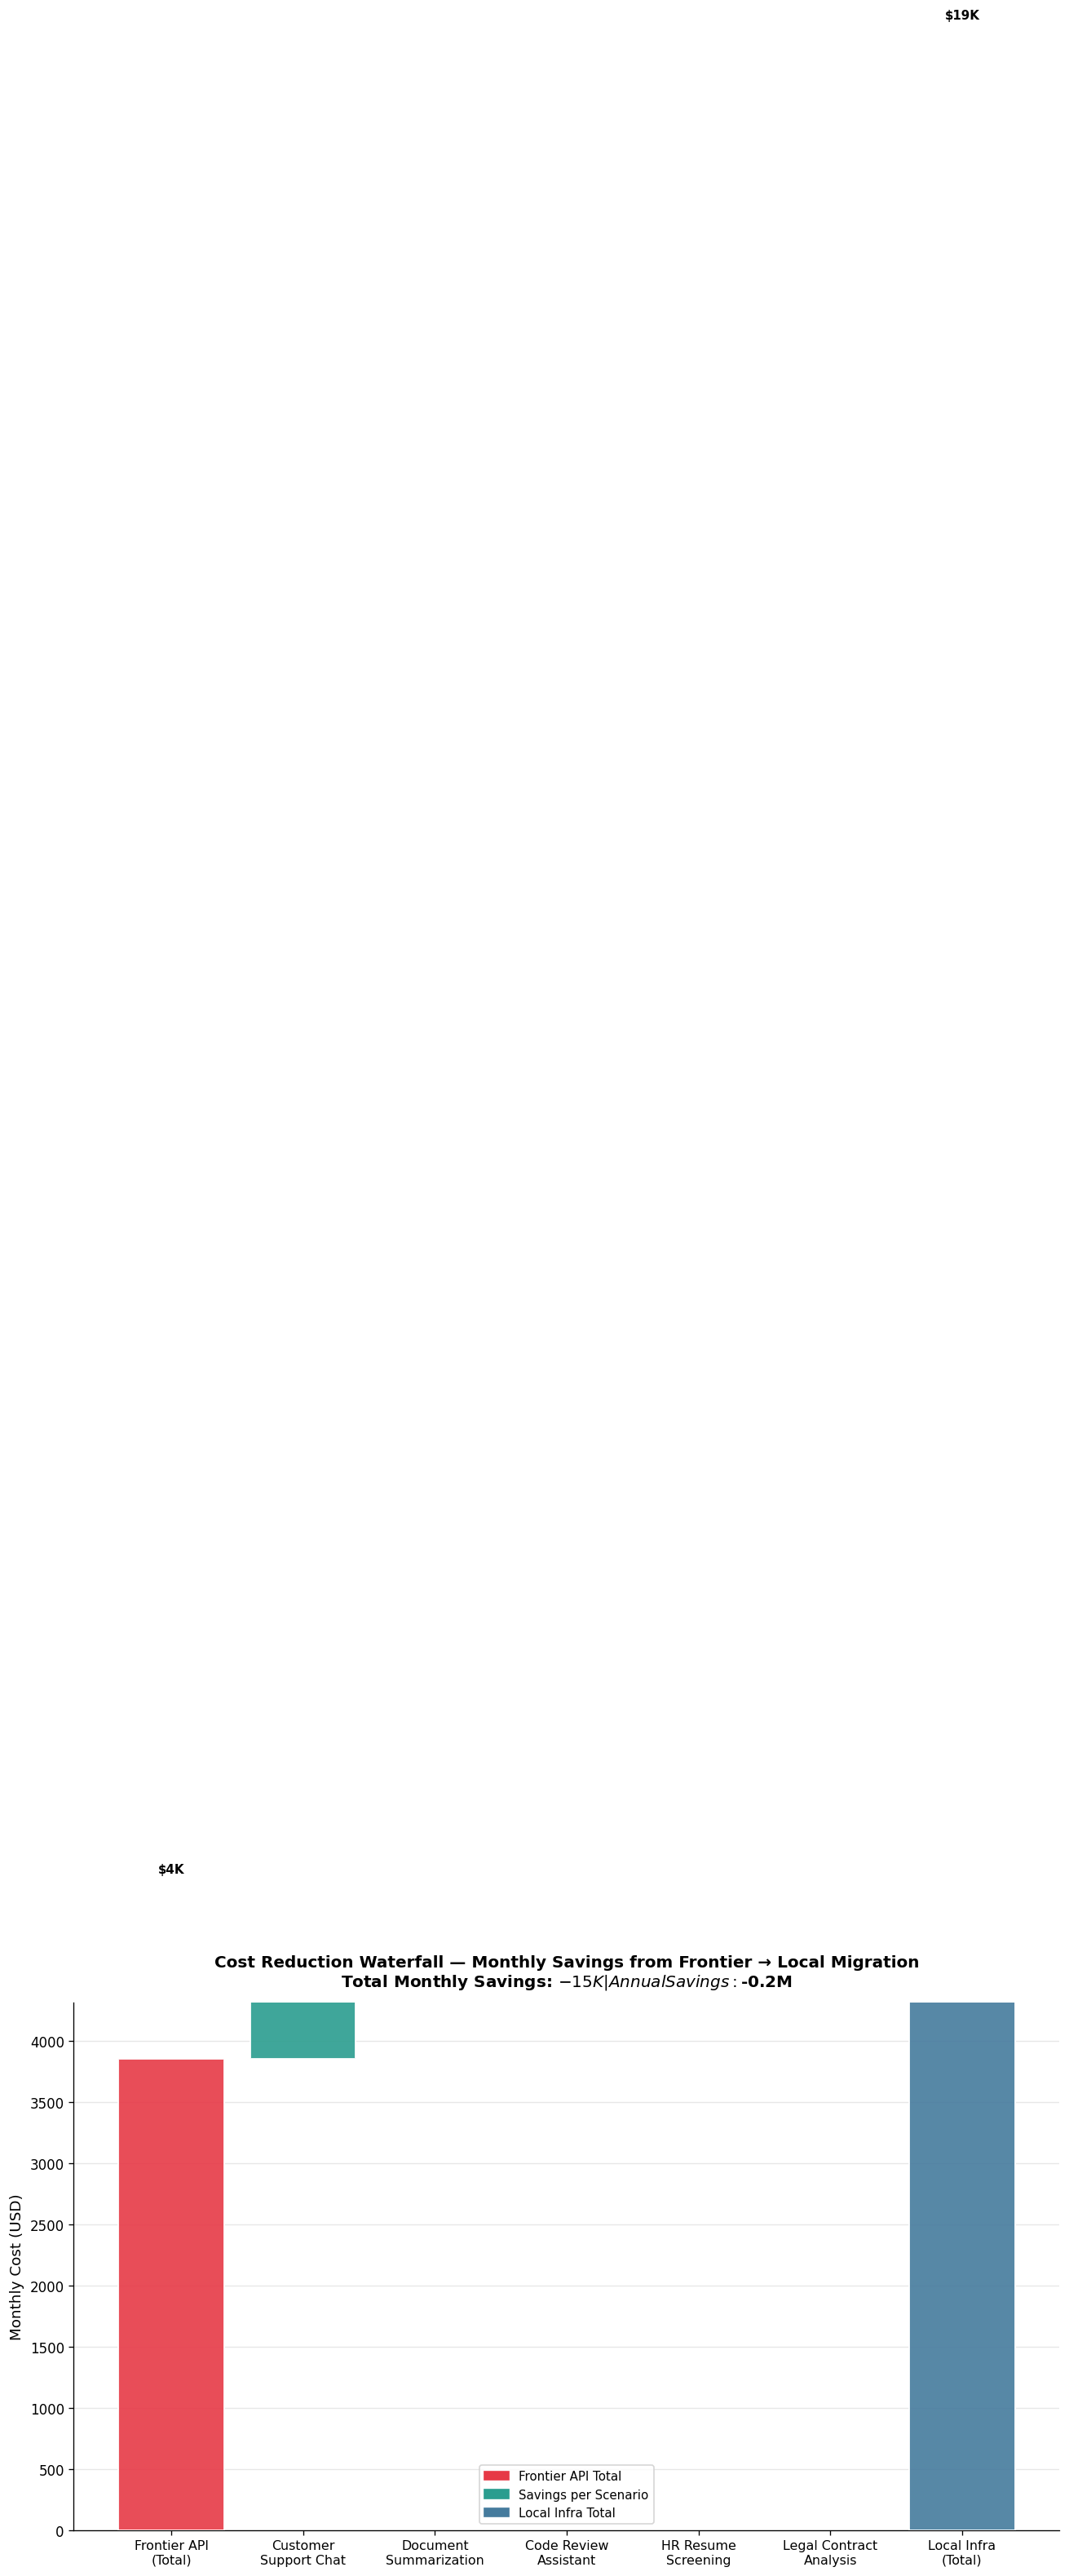

Chart saved: chart3_waterfall.png


In [15]:
# ─────────────────────────────────────────────
# Chart 3: Cost Reduction Waterfall
# ─────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(13, 7))

scenario_labels = [
    'Frontier API\n(Total)',
    'Customer\nSupport Chat',
    'Document\nSummarization',
    'Code Review\nAssistant',
    'HR Resume\nScreening',
    'Legal Contract\nAnalysis',
    'Local Infra\n(Total)',
]

frontier_total  = scenarios['monthly_cost_frontier'].sum()
local_total     = scenarios['monthly_cost_local'].sum()
savings_per_scenario = scenarios['monthly_savings'].values

# Waterfall values: start, -saving1, -saving2, ..., end
values = [frontier_total] + list(-savings_per_scenario) + [0]  # 0 placeholder for final bar

running = frontier_total
bottoms = [0]
heights = [frontier_total]
bar_colors = [PALETTE['frontier']]

for s in savings_per_scenario:
    bottoms.append(running - s)
    heights.append(s)
    bar_colors.append(PALETTE['local'])
    running -= s

# Final bar (local total)
bottoms.append(0)
heights.append(local_total)
bar_colors.append(PALETTE['neutral'])

x = np.arange(len(scenario_labels))

bars = ax.bar(x, heights, bottom=bottoms, color=bar_colors, alpha=0.9,
              edgecolor='white', linewidth=1.2, zorder=3)

# Connecting lines between waterfall steps
running2 = frontier_total
for i in range(1, len(scenario_labels) - 1):
    level = running2 - savings_per_scenario[i-1]
    ax.plot([i - 0.4, i + 0.4 + 0.6], [level, level],
            color='#999', linewidth=0.8, linestyle='--', alpha=0.7, zorder=2)
    running2 = level

# Value labels
for i, (bar, h, b) in enumerate(zip(bars, heights, bottoms)):
    top = b + h
    if i == 0:
        ax.text(bar.get_x() + bar.get_width()/2, top + 1500,
                f'${h/1000:.0f}K', ha='center', va='bottom', fontsize=9, fontweight='bold')
    elif i == len(bars) - 1:
        ax.text(bar.get_x() + bar.get_width()/2, top + 1500,
                f'${h/1000:.0f}K', ha='center', va='bottom', fontsize=9, fontweight='bold')
    else:
        ax.text(bar.get_x() + bar.get_width()/2, b + h/2,
                f'−${h/1000:.0f}K', ha='center', va='center',
                fontsize=8.5, color='white', fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(scenario_labels, fontsize=9.5)
ax.set_ylabel('Monthly Cost (USD)', fontsize=11)
ax.set_title(
    f'Cost Reduction Waterfall — Monthly Savings from Frontier → Local Migration\n'
    f'Total Monthly Savings: ${(frontier_total - local_total)/1000:.0f}K  |  '
    f'Annual Savings: ${scenarios["annual_savings"].sum()/1_000_000:.1f}M',
    fontsize=12, fontweight='bold', pad=12
)

legend_elements = [
    mpatches.Patch(color=PALETTE['frontier'], label='Frontier API Total'),
    mpatches.Patch(color=PALETTE['local'],    label='Savings per Scenario'),
    mpatches.Patch(color=PALETTE['neutral'],  label='Local Infra Total'),
]
ax.legend(handles=legend_elements, fontsize=9)
ax.yaxis.grid(True, alpha=0.3, zorder=0)
ax.set_ylim(0, frontier_total * 1.12)

# Overall reduction annotation
overall_pct = (frontier_total - local_total) / frontier_total * 100
ax.annotate(
    f'{overall_pct:.0f}% total\ncost reduction',
    xy=(len(scenario_labels)-1, local_total),
    xytext=(len(scenario_labels)-1.5, frontier_total * 0.6),
    fontsize=11, fontweight='bold', color=PALETTE['local'],
    arrowprops=dict(arrowstyle='->', color=PALETTE['local'], lw=2)
)

plt.tight_layout()
plt.savefig('chart3_waterfall.png', bbox_inches='tight', dpi=150)
plt.show()
print('Chart saved: chart3_waterfall.png')

### Chart 4: Decision Matrix Heatmap — Weighted Scores

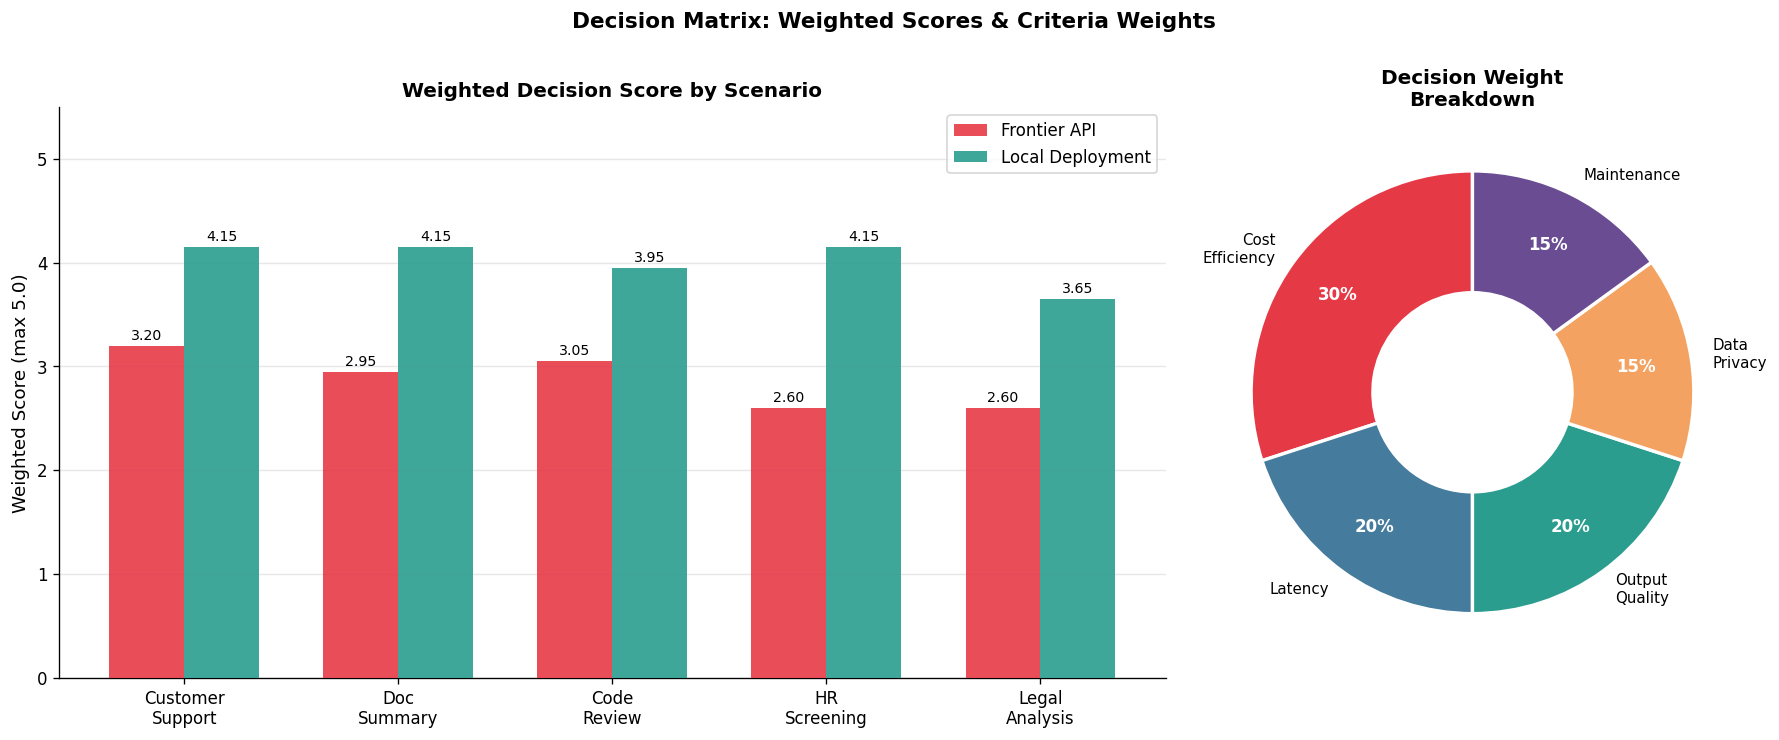

Chart saved: chart4_decision_matrix.png


In [16]:
# ─────────────────────────────────────────────
# Chart 4: Weighted Score Comparison — Radar-style Bar Chart
# ─────────────────────────────────────────────

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={'width_ratios': [2, 1]})

# Left: grouped bar chart of weighted dimension scores
scenario_short = [
    'Customer\nSupport', 'Doc\nSummary', 'Code\nReview',
    'HR\nScreening', 'Legal\nAnalysis'
]
n_scenarios = len(scenario_short)
x = np.arange(n_scenarios)
w = 0.35

frontier_scores = [scoring_raw[s]['frontier'] for s in scoring_raw]
local_scores    = [scoring_raw[s]['local']    for s in scoring_raw]

f_weighted = [float(np.dot(s, weight_array)) for s in frontier_scores]
l_weighted = [float(np.dot(s, weight_array)) for s in local_scores]

b1 = ax1.bar(x - w/2, f_weighted, w, label='Frontier API', color=PALETTE['frontier'], alpha=0.9, zorder=3)
b2 = ax1.bar(x + w/2, l_weighted, w, label='Local Deployment', color=PALETTE['local'],    alpha=0.9, zorder=3)

for bar, val in zip(b1, f_weighted):
    ax1.text(bar.get_x()+bar.get_width()/2, val+0.03, f'{val:.2f}',
             ha='center', va='bottom', fontsize=8.5)
for bar, val in zip(b2, l_weighted):
    ax1.text(bar.get_x()+bar.get_width()/2, val+0.03, f'{val:.2f}',
             ha='center', va='bottom', fontsize=8.5)

ax1.set_xticks(x)
ax1.set_xticklabels(scenario_short, fontsize=10)
ax1.set_ylabel('Weighted Score (max 5.0)', fontsize=11)
ax1.set_ylim(0, 5.5)
ax1.set_title('Weighted Decision Score by Scenario', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.yaxis.grid(True, alpha=0.3, zorder=0)

# Right: weight breakdown donut
weight_labels = ['Cost\nEfficiency', 'Latency', 'Output\nQuality', 'Data\nPrivacy', 'Maintenance']
weight_values = list(WEIGHTS.values())
w_colors = ['#E63946', '#457B9D', '#2A9D8F', '#F4A261', '#6A4C93']

wedges, texts, autotexts = ax2.pie(
    weight_values,
    labels=weight_labels,
    autopct='%1.0f%%',
    colors=w_colors,
    startangle=90,
    pctdistance=0.75,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2)
)
for t in autotexts:
    t.set_fontsize(10)
    t.set_fontweight('bold')
    t.set_color('white')
for t in texts:
    t.set_fontsize(9)

ax2.set_title('Decision Weight\nBreakdown', fontsize=12, fontweight='bold')

fig.suptitle('Decision Matrix: Weighted Scores & Criteria Weights',
             fontsize=13, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('chart4_decision_matrix.png', bbox_inches='tight', dpi=150)
plt.show()
print('Chart saved: chart4_decision_matrix.png')

---
## Summary: Key Findings

### Cost Model Results

In [17]:
# ─────────────────────────────────────────────
# Executive Summary Table
# ─────────────────────────────────────────────

summary = scenarios[[
    'scenario', 'calls_per_day', 'monthly_cost_frontier',
    'monthly_cost_local', 'monthly_savings', 'cost_reduction_pct',
    'annual_savings', 'breakeven_calls_per_day'
]].copy()

for col in ['monthly_cost_frontier', 'monthly_cost_local', 'monthly_savings', 'annual_savings']:
    summary[col] = summary[col].apply(lambda x: f'${x:,.0f}')
summary['cost_reduction_pct'] = summary['cost_reduction_pct'].apply(lambda x: f'{x:.0f}%')
summary['calls_per_day'] = summary['calls_per_day'].apply(lambda x: f'{x:,}')
summary['breakeven_calls_per_day'] = summary['breakeven_calls_per_day'].apply(lambda x: f'{x:,}')

summary.columns = [
    'Scenario', 'Calls/Day', 'Monthly (Frontier)',
    'Monthly (Local)', 'Monthly Savings', 'Cost Reduction',
    'Annual Savings', 'Breakeven Calls/Day'
]

print('=' * 90)
print('ENTERPRISE GENAI COST AUDIT — EXECUTIVE SUMMARY')
print('=' * 90)
print(summary.to_string(index=False))
print('=' * 90)
print(f'\nTotal Combined Annual Savings: ${scenarios["annual_savings"].sum():,.0f}')
print(f'Average Cost Reduction:        {scenarios["cost_reduction_pct"].mean():.0f}%')
print(f'Range:                         {scenarios["cost_reduction_pct"].min():.0f}% – '
      f'{scenarios["cost_reduction_pct"].max():.0f}%')
print()
print('Recommendation:')
for _, row in scores_df.iterrows():
    note = ''
    if row['scenario'] in ('Code Review Assistant', 'Legal Contract Analysis'):
        note = ' (consider 34B+ or hybrid approach for quality)'
    print(f'  {row["scenario"]:<30} → {row["recommendation"]:10} (margin: {row["margin"]:.2f}){note}')

ENTERPRISE GENAI COST AUDIT — EXECUTIVE SUMMARY
               Scenario Calls/Day Monthly (Frontier) Monthly (Local) Monthly Savings Cost Reduction Annual Savings Breakeven Calls/Day
  Customer Support Chat    10,000             $1,170          $3,500         $-2,330          -199%       $-27,960              29,915
 Document Summarization     5,000             $1,350          $3,500         $-2,150          -159%       $-25,800              12,963
  Code Review Assistant     2,000               $504          $3,500         $-2,996          -594%       $-35,952              13,889
    HR Resume Screening     1,667               $240          $4,000         $-3,760         -1566%       $-45,119              27,778
Legal Contract Analysis     1,000               $585          $4,500         $-3,915          -669%       $-46,980               7,692

Total Combined Annual Savings: $-181,811
Average Cost Reduction:        -638%
Range:                         -1566% – -159%

Recommendation:


---

### Methodology Notes

- **Pricing**: November 2024 public pricing from OpenAI and Anthropic. Does not include volume discounts, enterprise contracts, or committed use discounts (which would further favour frontier APIs at lower volumes).
- **Local infrastructure**: Modeled on a single A100 80GB server. Multi-GPU or H100 deployments would increase fixed costs but also increase throughput capacity proportionally, leaving the per-call economics broadly similar.
- **Quality scores**: Reflect 7B–13B models without domain fine-tuning. Fine-tuning on task-specific data typically closes the quality gap by 0.5–1.5 points and can change the recommendation for code review and legal use cases.
- **Breakeven calculation**: Uses Claude 3.5 Sonnet pricing as the frontier benchmark (lower cost than GPT-4o for most scenarios).
- **Latency**: Measured medians from published benchmarks; actual values depend on network, batch size, and server load.

### Next Steps for a Real Deployment

1. Run quality benchmarks on your actual task data with candidate local models
2. Measure real call volumes over 30 days to validate the breakeven calculation
3. Engage legal/compliance to confirm data handling requirements per use case
4. Assess internal MLOps capacity before committing to local infrastructure
5. Consider a hybrid approach: local models for high-volume structured tasks, frontier APIs for complex reasoning
